In [1]:
!pip install --upgrade scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 105.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

In [4]:
from google.colab import drive
drive.mount('/content/drive')

# Update this path to where your CSV lives in Drive
CSV_PATH = '/content/drive/MyDrive/Colab_Notebooks/itineraries_sample.csv'
# flight_sample = pd.read_csv(CSV_PATH)
# flight_sample.head()
df = pd.read_csv(CSV_PATH)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# df = flight_sample.copy()

# dates & booking window
df['searchDate'] = pd.to_datetime(df['searchDate'], errors='coerce')
df['flightDate'] = pd.to_datetime(df['flightDate'], errors='coerce')
df = df.dropna(subset=['searchDate', 'flightDate'])
df['booking_window'] = (df['flightDate'] - df['searchDate']).dt.days.clip(lower=0, upper=365)

# legs count
def _count_legs(s):
    if pd.isna(s) or s == '':
        return 0
    return str(s).count('||') + 1

src_col = 'segmentsDepartureTimeRaw' if 'segmentsDepartureTimeRaw' in df.columns else (
          'segmentsDepartureTimeEpochSeconds' if 'segmentsDepartureTimeEpochSeconds' in df.columns else None)
df['num_legs'] = df[src_col].apply(_count_legs) if src_col else 1  # fallback: 1

# route distance (totalTravelDistance else sum(segmentsDistance))
def _sum_segments_nums(s):
    if pd.isna(s):
        return np.nan
    return np.nansum(pd.to_numeric(str(s).split('||'), errors='coerce'))

df['route_distance'] = pd.to_numeric(df.get('totalTravelDistance', np.nan), errors='coerce')
if 'segmentsDistance' in df.columns:
    seg_dist = df['segmentsDistance'].apply(_sum_segments_nums)
    df['route_distance'] = df['route_distance'].fillna(seg_dist)

# winsorize route_distance to cut extreme outliers
if df['route_distance'].notna().any():
    q1, q99 = df['route_distance'].quantile([0.01, 0.99])
    df['route_distance'] = df['route_distance'].clip(lower=q1, upper=q99)

# clean booleans & seats
for c in ['isNonStop', 'isRefundable', 'isBasicEconomy']:
    if c in df.columns:
        df[c] = df[c].astype(int)

df['seatsRemaining'] = pd.to_numeric(df['seatsRemaining'], errors='coerce')

# ------------------------------------------------------------------
# 2. Build X: use all features EXCEPT baseFare & totalFare (and log_price if it exists)
# ------------------------------------------------------------------
# drop_cols = ['baseFare', 'totalFare', 'log_price']
# drop_cols = [c for c in drop_cols if c in df.columns]
# X = df.drop(columns=drop_cols)

# ------------------------------------------------------------------
# SAMPLE 100 ROWS FOR TESTING PCA
# ------------------------------------------------------------------

df_small = df.sample(n=5000, random_state=42).reset_index(drop=True)

# Drop fares from features for PCA
drop_cols = ['baseFare', 'totalFare', 'log_price']
drop_cols = [c for c in drop_cols if c in df_small.columns]

X_small = df_small.drop(columns=drop_cols)


# identify numeric vs categorical columns after the preprocessing above
# numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
# categorical_features = X.select_dtypes(exclude=['int64', 'float64']).columns.tolist()
numeric_features = X_small.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X_small.select_dtypes(exclude=['int64', 'float64']).columns.tolist()


print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

# ------------------------------------------------------------------
# 3. Preprocessing + PCA pipeline
#    (note: OneHotEncoder returns DENSE output because PCA needs dense)
# ------------------------------------------------------------------
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

pre = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

# keep enough components to explain 95% of the variance
pca = PCA(n_components=0.95, svd_solver='full', random_state=0)

pca_pipe = Pipeline(
    steps=[
        ('pre', pre),
        ('pca', pca),
    ]
)

# ------------------------------------------------------------------
# 4. Fit PCA
# ------------------------------------------------------------------
# X_pca = pca_pipe.fit_transform(X)
X_pca = pca_pipe.fit_transform(X_small)

print("Encoded feature dimension:",
      pca_pipe.named_steps['pre'].transform(X_small).shape[1])
print("Number of principal components:", X_pca.shape[1])

explained_var = pca_pipe.named_steps['pca'].explained_variance_ratio_
print("Explained variance ratio:", explained_var)
print("Cumulative explained variance:", np.cumsum(explained_var))


# print("Encoded feature dimension:",
#       pca_pipe.named_steps['pre'].transform(X).shape[1])
# print("Number of principal components:", X_pca.shape[1])

# explained_var = pca_pipe.named_steps['pca'].explained_variance_ratio_
# print("Explained variance ratio:", explained_var)
# print("Cumulative explained variance:", np.cumsum(explained_var))

# (optional) put PCs in a DataFrame
pc_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pc_cols)
X_pca_df.head()

Numeric features: ['elapsedDays', 'isBasicEconomy', 'isRefundable', 'isNonStop', 'seatsRemaining', 'totalTravelDistance', 'booking_window', 'num_legs', 'route_distance']
Categorical features: ['legId', 'searchDate', 'flightDate', 'startingAirport', 'destinationAirport', 'fareBasisCode', 'travelDuration', 'segmentsDepartureTimeEpochSeconds', 'segmentsDepartureTimeRaw', 'segmentsArrivalTimeEpochSeconds', 'segmentsArrivalTimeRaw', 'segmentsArrivalAirportCode', 'segmentsDepartureAirportCode', 'segmentsAirlineName', 'segmentsAirlineCode', 'segmentsEquipmentDescription', 'segmentsDurationInSeconds', 'segmentsDistance', 'segmentsCabinCode']
Encoded feature dimension: 34474
Number of principal components: 3797
Explained variance ratio: [1.17589652e-01 6.15169688e-02 5.59501179e-02 ... 4.87803092e-05
 4.87741340e-05 4.87695509e-05]
Cumulative explained variance: [0.11758965 0.17910662 0.23505674 ... 0.94990415 0.94995292 0.95000169]


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC3788,PC3789,PC3790,PC3791,PC3792,PC3793,PC3794,PC3795,PC3796,PC3797
0,0.032908,0.077063,-0.785954,-0.220578,-0.619319,1.146788,-0.703458,-0.564144,1.027737,0.023416,...,-0.027911,0.037363,0.052100,0.004594,-0.057777,0.002288,0.015214,-0.056780,0.001162,0.030025
1,0.783559,-0.260783,-0.832187,-1.340249,-0.864164,1.987607,1.173919,0.361079,-0.062239,-0.041477,...,0.015801,0.027804,0.027594,0.048129,0.062472,0.015893,-0.002634,-0.008748,-0.028285,0.044730
2,-0.401295,-0.752277,-1.170473,0.952343,-0.456590,0.999783,-0.479276,-0.086377,-0.030595,-0.439022,...,-0.137253,-0.013008,-0.009382,-0.071829,0.108433,-0.004793,0.113766,0.015482,-0.060133,-0.008547
3,1.400958,-0.123570,0.616637,1.000049,-0.777337,-0.257537,-0.609225,-0.682525,0.942287,-0.522135,...,0.029260,0.010771,-0.038150,0.022177,-0.078998,-0.037019,-0.012206,0.037486,0.008354,0.042894
4,-0.144412,-3.103991,-0.822816,-1.287994,-0.146953,-1.144742,0.347104,-0.855506,0.103552,0.237841,...,-0.037505,-0.076753,0.030065,-0.057567,0.020905,0.062481,-0.088987,-0.099999,0.063982,0.080714


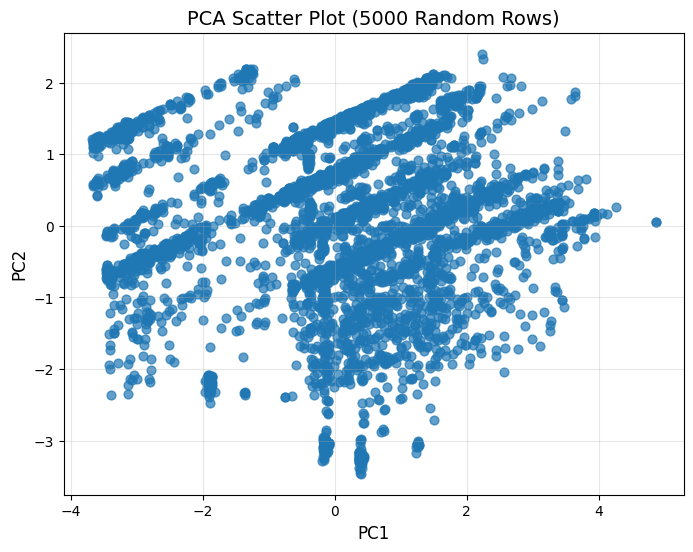

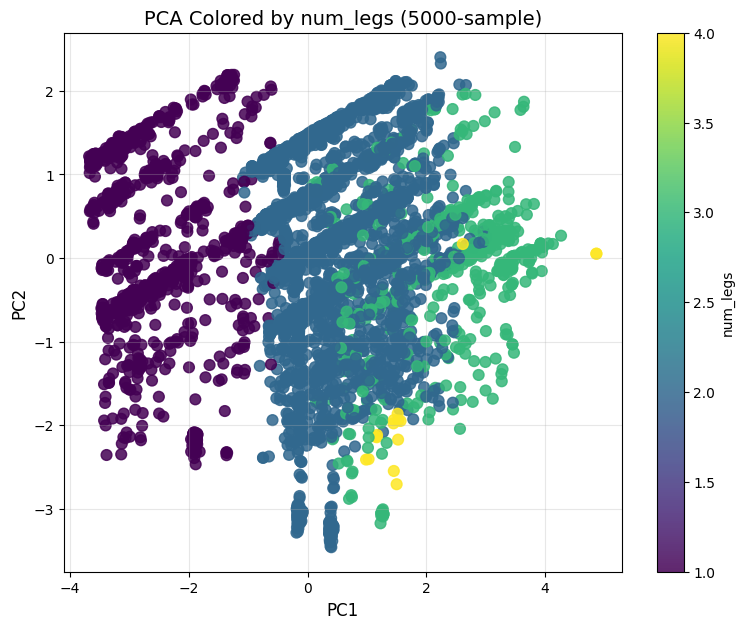

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------------
# 1. Scatter Plot: PC1 vs PC2
# ---------------------------------------------------------------

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=40, alpha=0.7)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title("PCA Scatter Plot (5000 Random Rows)", fontsize=14)
plt.grid(alpha=0.3)
plt.show()


# ---------------------------------------------------------------
# 2. Scatter Plot Colored by any column in df_small
#    Change this to explore different patterns
# ---------------------------------------------------------------

color_feature = "num_legs"   # Also can change to: "startingAirport", "isNonStop", "route_distance", ...

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df_small[color_feature],
    cmap="viridis",
    s=60,
    alpha=0.85
)
plt.colorbar(sc, label=color_feature)
plt.xlabel("PC1", fontsize=12)
plt.ylabel("PC2", fontsize=12)
plt.title(f"PCA Colored by {color_feature} (5000-sample)", fontsize=14)
plt.grid(alpha=0.3)
plt.show()